In [6]:
import os
import glob
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import ops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [7]:
ROOT_DIR = r"E:\WISDM_ar_v1.1\PAMAP2_Dataset"

ABLATION_ROOT = r"E:\WISDM_ar_v1.1\ABLATION_STUDY"

PAMAP2_OUT = os.path.join(ABLATION_ROOT, "PAMAP2")

DIRS = {
    "models": os.path.join(PAMAP2_OUT, "models"),
    "reports": os.path.join(PAMAP2_OUT, "reports"),
    "plots": os.path.join(PAMAP2_OUT, "plots"),
    "tflite": os.path.join(PAMAP2_OUT, "tflite")
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [8]:
FEATURE_IDXS = [
    2,4,5,6,
    10,11,12,
    21,22,23,
    27,28,29,
    38,39,40,
    44,45,46
]

FEATURE_NAMES = [
    "hr",

    "hand_acc_x","hand_acc_y","hand_acc_z",
    "hand_gyro_x","hand_gyro_y","hand_gyro_z",

    "chest_acc_x","chest_acc_y","chest_acc_z",
    "chest_gyro_x","chest_gyro_y","chest_gyro_z",

    "ankle_acc_x","ankle_acc_y","ankle_acc_z",
    "ankle_gyro_x","ankle_gyro_y","ankle_gyro_z"
]

dat_files = sorted(
    glob.glob(
        os.path.join(ROOT_DIR, "**", "*.dat"),
        recursive=True
    )
)

print("Found .dat files:", len(dat_files))

dfs = []

for file in dat_files:

    temp = pd.read_csv(
        file,
        sep=r"\s+",
        header=None
    )

    keep = [1] + FEATURE_IDXS

    sub = temp.iloc[:, keep].copy()

    sub.columns = ["activity_id"] + FEATURE_NAMES

    dfs.append(sub)

data = pd.concat(dfs, ignore_index=True)

data = data[data["activity_id"] != 0]

data.replace([np.inf, -np.inf], np.nan, inplace=True)

data.dropna(inplace=True)

data.reset_index(drop=True, inplace=True)

print(data.shape)

data.head()

Found .dat files: 28
(493424, 20)


,activity_id,hr,hand_acc_x,hand_acc_y,hand_acc_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,chest_acc_x,chest_acc_y,chest_acc_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z
0,11,123.0,1.16443,7.41807,5.95957,0.026416,0.034762,-0.101909,-0.288562,9.84091,-1.46631,0.045573,-0.011807,-0.100515,7.92515,-3.15747,-5.51080,0.014681,-0.034401,0.022202
1,11,123.0,1.92182,8.01859,5.89191,0.032131,0.084861,-0.018329,-0.482120,9.57741,-1.54640,-0.029630,0.013569,-0.036261,7.69540,-3.30664,-5.66659,-0.040359,0.003235,0.014533
2,11,123.0,1.50401,7.33957,5.96492,-0.067660,-0.127681,0.010273,-0.097045,9.76526,-1.42388,-0.049371,0.012373,-0.022111,7.69690,-3.23102,-5.62845,-0.001756,-0.013018,-0.006787
3,11,123.0,1.64526,7.63889,5.61964,-0.017410,-0.203416,-0.068390,-0.247016,9.84156,-1.34940,0.000960,-0.016363,-0.015964,7.88803,-3.30943,-5.47165,0.006662,-0.015803,-0.010730
4,11,123.0,1.73963,8.35283,4.92587,0.074731,-0.065739,-0.077783,-0.290104,9.69003,-1.50457,0.041378,0.083886,-0.021857,7.80847,-3.15547,-5.66637,0.002974,-0.026768,0.013577


In [9]:
activity_ids = sorted(data["activity_id"].unique())

id2idx = {
    a: i for i, a in enumerate(activity_ids)
}

idx2id = {
    i: a for a, i in id2idx.items()
}

print("Activities:", activity_ids)
print("Total Classes:", len(activity_ids))

Activities: [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 24]
Total Classes: 18


In [10]:
WIN = 200
STEP = 100

Xw = []
yw = []

X = data[FEATURE_NAMES].values.astype(np.float32)

y = data["activity_id"].map(id2idx).values.astype(np.int32)

for i in range(0, len(X) - WIN + 1, STEP):

    xs = X[i:i+WIN]
    ys = y[i:i+WIN]

    label = np.bincount(ys).argmax()

    Xw.append(xs)
    yw.append(label)

Xw = np.array(Xw, dtype=np.float32)
yw = np.array(yw, dtype=np.int32)

print("Windows:", Xw.shape)
print("Labels:", yw.shape)

Windows: (4933, 200, 19)
Labels: (4933,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    Xw,
    yw,
    test_size=0.2,
    stratify=yw,
    random_state=SEED
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_s = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

X_train_s = X_train_s.astype(np.float32)
X_test_s = X_test_s.astype(np.float32)

print("Train:", X_train_s.shape)
print("Test:", X_test_s.shape)

Train: (3946, 200, 19)
Test: (987, 200, 19)


In [12]:
def encoder_block(
    x,
    d_model,
    num_heads,
    mlp_dim,
    dropout
):

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout
    )(x, x)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x + attn)

    ff = layers.Dense(
        mlp_dim,
        activation="gelu"
    )(x)

    ff = layers.Dropout(dropout)(ff)

    ff = layers.Dense(d_model)(ff)

    ff = layers.Dropout(dropout)(ff)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x + ff)

    return x

In [13]:
def build_transformer(
    input_shape,
    num_classes,
    patch_len,
    depth
):

    d_model = 96
    num_heads = 4
    mlp_dim = 192
    dropout = 0.15

    inp = keras.Input(shape=input_shape)

    x = layers.Conv1D(
        filters=d_model,
        kernel_size=patch_len,
        strides=patch_len,
        padding="valid"
    )(inp)

    seq_len = ops.shape(x)[1]

    pos = ops.arange(
        start=0,
        stop=seq_len,
        step=1
    )

    pos_emb = layers.Embedding(
        input_dim=4096,
        output_dim=d_model
    )(pos)

    pos_emb = ops.expand_dims(pos_emb, axis=0)

    x = x + pos_emb

    x = layers.Dropout(dropout)(x)

    for _ in range(depth):

        x = encoder_block(
            x,
            d_model=d_model,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout
        )

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dropout(dropout)(x)

    out = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
PATCH_LIST = [1, 5, 10, 15, 20, 25]

DEPTH_LIST = [1, 2, 3, 4]

configs = []

for patch_len in PATCH_LIST:

    for depth in DEPTH_LIST:

        name = f"Patch{patch_len}_Depth{depth}"

        if patch_len == 1:
            name = f"NoPatch_Depth{depth}"

        configs.append({
            "name": name,
            "patch_len": patch_len,
            "depth": depth
        })

print("Total Experiments:", len(configs))

configs[:5]

Total Experiments: 24


[{'name': 'NoPatch_Depth1', 'patch_len': 1, 'depth': 1},
 {'name': 'NoPatch_Depth2', 'patch_len': 1, 'depth': 2},
 {'name': 'NoPatch_Depth3', 'patch_len': 1, 'depth': 3},
 {'name': 'NoPatch_Depth4', 'patch_len': 1, 'depth': 4},
 {'name': 'Patch5_Depth1', 'patch_len': 5, 'depth': 1}]

In [15]:
def evaluate_model(model):

    probs = model.predict(
        X_test_s,
        verbose=0
    )

    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, preds)

    f1 = f1_score(
        y_test,
        preds,
        average="macro"
    )

    return acc, f1


def measure_latency(model):

    sample = X_test_s[:1]

    for _ in range(10):
        model.predict(sample, verbose=0)

    start = time.time()

    for _ in range(100):
        model.predict(sample, verbose=0)

    end = time.time()

    latency = ((end - start) / 100) * 1000

    return latency

In [16]:
results = []

for cfg in configs:

    print("\n" + "="*80)
    print("Training:", cfg["name"])
    print("="*80)

    tf.keras.backend.clear_session()

    model = build_transformer(
        input_shape=X_train_s.shape[1:],
        num_classes=len(activity_ids),
        patch_len=cfg["patch_len"],
        depth=cfg["depth"]
    )

    callbacks = [

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        X_train_s,
        y_train,
        validation_split=0.1,
        epochs=20,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )

    acc, f1 = evaluate_model(model)

    latency = measure_latency(model)

    model_path = os.path.join(
        DIRS["models"],
        cfg["name"] + ".keras"
    )

    model.save(model_path)

    size_kb = os.path.getsize(model_path) / 1024

    params = model.count_params()

    results.append({

        "Configuration": cfg["name"],

        "Patch Length": cfg["patch_len"],

        "Encoder Layers": cfg["depth"],

        "Accuracy (%)": round(acc * 100, 2),

        "Macro F1 (%)": round(f1 * 100, 2),

        "Latency (ms)": round(latency, 2),

        "Model Size (KB)": round(size_kb, 2),

        "Parameters": params
    })

    temp_df = pd.DataFrame(results)

    running_csv = os.path.join(
        DIRS["reports"],
        "PAMAP2_RUNNING_RESULTS.csv"
    )

    temp_df.to_csv(running_csv, index=False)

    print(temp_df.tail(1))


Training: NoPatch_Depth1

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.6280 - loss: 1.2950 - val_accuracy: 0.8430 - val_loss: 0.5578 - learning_rate: 0.0010
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.8609 - loss: 0.5062 - val_accuracy: 0.8987 - val_loss: 0.3802 - learning_rate: 0.0010
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.9127 - loss: 0.3325 - val_accuracy: 0.9190 - val_loss: 0.2846 - learning_rate: 0.0010
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.9341 - loss: 0.2502 - val_accuracy: 0.9342 - val_loss: 0.2483 - learning_rate: 0.0010
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.9445 - loss: 0.2043 - val_accuracy: 0.9291 - val_loss: 0.2290 - learning_rate: 0.0010
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.9569 - loss: 0.1700 - val_accuracy: 0.9443 - val_loss: 0.1767 - learning_rate: 0.0010
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accura

In [17]:
results_df = pd.DataFrame(results)

final_csv = os.path.join(
    DIRS["reports"],
    "PAMAP2_FINAL_RESULTS.csv"
)

results_df.to_csv(final_csv, index=False)

print("Saved:", final_csv)

results_df

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\PAMAP2\reports\PAMAP2_FINAL_RESULTS.csv


,Configuration,Patch Length,Encoder Layers,Accuracy (%),Macro F1 (%),Latency (ms),Model Size (KB),Parameters
0,NoPatch_Depth1,1,1,98.48,98.11,136.06,1414.26,78450
1,NoPatch_Depth2,1,2,99.19,99.13,145.49,2338.43,153234
2,NoPatch_Depth3,1,3,97.67,97.65,143.02,3264.63,228018
3,NoPatch_Depth4,1,4,98.99,98.89,160.13,4189.37,302802
4,Patch5_Depth1,5,1,98.07,97.57,136.96,1167.55,85746
5,Patch5_Depth2,5,2,98.07,97.55,135.37,2091.85,160530
6,Patch5_Depth3,5,3,97.87,97.77,137.44,3017.99,235314
7,Patch5_Depth4,5,4,98.48,98.25,151.85,3942.59,310098
8,Patch10_Depth1,10,1,97.47,97.46,132.64,1232.80,94866
9,Patch10_Depth2,10,2,97.47,96.58,145.87,2157.20,169650


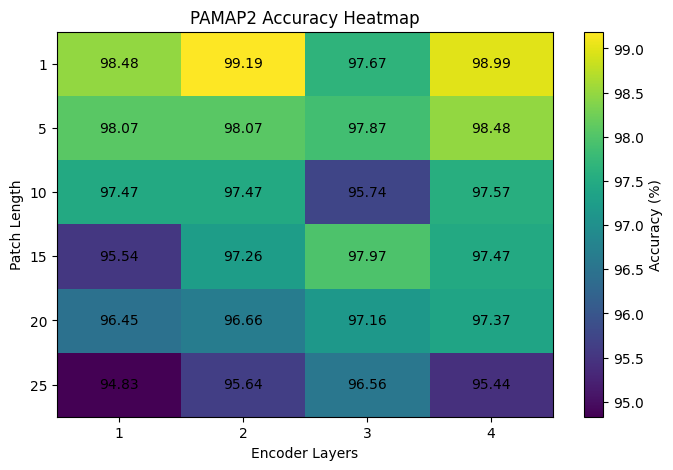

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\PAMAP2\plots\PAMAP2_ACCURACY_HEATMAP.png


In [18]:
pivot_acc = results_df.pivot(
    index="Patch Length",
    columns="Encoder Layers",
    values="Accuracy (%)"
)

plt.figure(figsize=(8,5))

plt.imshow(pivot_acc, aspect="auto")

plt.xticks(
    range(len(pivot_acc.columns)),
    pivot_acc.columns
)

plt.yticks(
    range(len(pivot_acc.index)),
    pivot_acc.index
)

for i in range(len(pivot_acc.index)):

    for j in range(len(pivot_acc.columns)):

        plt.text(
            j,
            i,
            f"{pivot_acc.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Encoder Layers")

plt.ylabel("Patch Length")

plt.title("PAMAP2 Accuracy Heatmap")

plt.colorbar(label="Accuracy (%)")

plot_path = os.path.join(
    DIRS["plots"],
    "PAMAP2_ACCURACY_HEATMAP.png"
)

plt.savefig(
    plot_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:", plot_path)

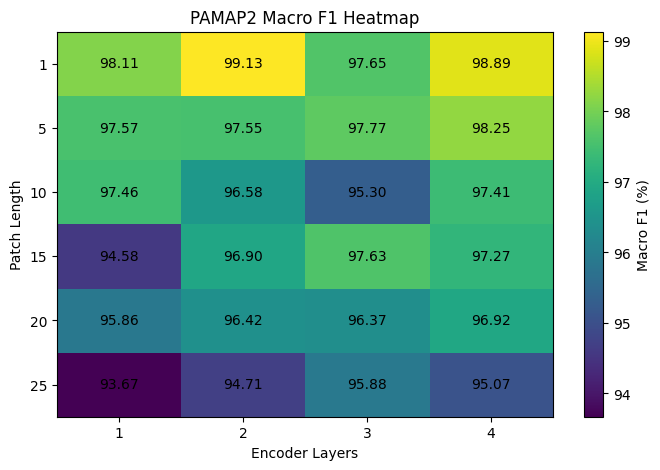

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\PAMAP2\plots\PAMAP2_MACRO_F1_HEATMAP.png


In [19]:
# ============================================================
# PAMAP2 Macro F1 Heatmap
# ============================================================

pivot_f1 = results_df.pivot(
    index="Patch Length",
    columns="Encoder Layers",
    values="Macro F1 (%)"
)

plt.figure(figsize=(8, 5))

plt.imshow(pivot_f1, aspect="auto")

plt.xticks(
    range(len(pivot_f1.columns)),
    pivot_f1.columns
)

plt.yticks(
    range(len(pivot_f1.index)),
    pivot_f1.index
)

for i in range(len(pivot_f1.index)):

    for j in range(len(pivot_f1.columns)):

        plt.text(
            j,
            i,
            f"{pivot_f1.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Encoder Layers")
plt.ylabel("Patch Length")
plt.title("PAMAP2 Macro F1 Heatmap")

plt.colorbar(label="Macro F1 (%)")

plot_path = os.path.join(
    DIRS["plots"],
    "PAMAP2_MACRO_F1_HEATMAP.png"
)

plt.savefig(
    plot_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:", plot_path)

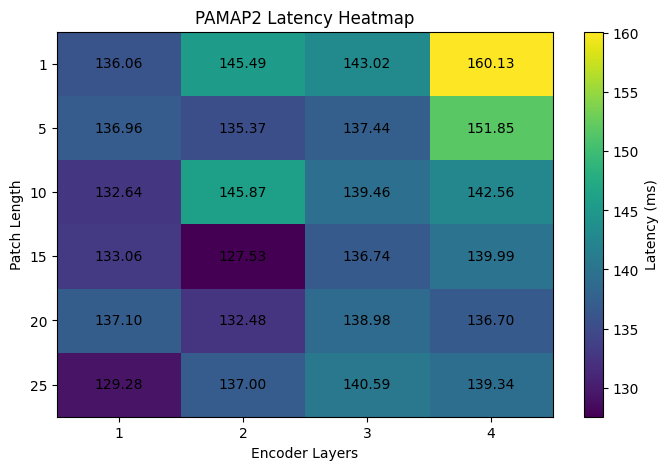

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\PAMAP2\plots\PAMAP2_LATENCY_HEATMAP.png


In [20]:
# ============================================================
# PAMAP2 Latency Heatmap
# ============================================================

pivot_latency = results_df.pivot(
    index="Patch Length",
    columns="Encoder Layers",
    values="Latency (ms)"
)

plt.figure(figsize=(8, 5))

plt.imshow(pivot_latency, aspect="auto")

plt.xticks(
    range(len(pivot_latency.columns)),
    pivot_latency.columns
)

plt.yticks(
    range(len(pivot_latency.index)),
    pivot_latency.index
)

for i in range(len(pivot_latency.index)):

    for j in range(len(pivot_latency.columns)):

        plt.text(
            j,
            i,
            f"{pivot_latency.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Encoder Layers")
plt.ylabel("Patch Length")
plt.title("PAMAP2 Latency Heatmap")

plt.colorbar(label="Latency (ms)")

plot_path = os.path.join(
    DIRS["plots"],
    "PAMAP2_LATENCY_HEATMAP.png"
)

plt.savefig(
    plot_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:", plot_path)

In [21]:
BEST_CONFIG = "Patch10_Depth3"

best_model_path = os.path.join(
    DIRS["models"],
    BEST_CONFIG + ".keras"
)

best_model = keras.models.load_model(best_model_path)

print("Loaded model:", best_model_path)
best_model.summary()

Loaded model: E:\WISDM_ar_v1.1\ABLATION_STUDY\PAMAP2\models\Patch10_Depth3.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 19)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 20, 96)    │     18,336 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 96)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 96)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 96)    │     37,248 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 96)    │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 96)    │        192 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20, 192)   │     18,624 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 20, 192)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 96)    │     18,528 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 20, 96)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 96)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 96)    │        192 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 96)    │     37,248 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 96)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 96)    │        192 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20, 192)   │     18,624 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 20, 192)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 20, 96)    │     18,528 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 20, 96)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 733,304 (2.80 MB)

 Trainable params: 244,434 (954.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 488,870 (1.86 MB)

In [22]:
import tempfile

def convert_to_tflite(model, quant_type="fp32", representative_data=None):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    if quant_type == "fp32":
        pass

    elif quant_type == "fp16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif quant_type == "int8_dynamic":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

    elif quant_type == "int8_full":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

        def representative_dataset():
            for i in range(min(300, len(representative_data))):
                yield [representative_data[i:i+1].astype(np.float32)]

        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS_INT8
        ]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8

    return converter.convert()

In [23]:
def evaluate_tflite_model(tflite_model, X_test, y_test):
    with tempfile.NamedTemporaryFile(suffix=".tflite", delete=False) as f:
        f.write(tflite_model)
        temp_model_path = f.name

    interpreter = tf.lite.Interpreter(model_path=temp_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    preds = []

    for i in range(len(X_test)):
        x = X_test[i:i+1].astype(np.float32)

        if input_details[0]["dtype"] == np.int8:
            scale, zero_point = input_details[0]["quantization"]
            x = x / scale + zero_point
            x = np.clip(x, -128, 127).astype(np.int8)

        interpreter.set_tensor(input_details[0]["index"], x)
        interpreter.invoke()

        out = interpreter.get_tensor(output_details[0]["index"])

        if output_details[0]["dtype"] == np.int8:
            scale, zero_point = output_details[0]["quantization"]
            out = scale * (out.astype(np.float32) - zero_point)

        preds.append(np.argmax(out))

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")

    return acc, f1


def measure_tflite_latency(tflite_model, X_test, warmup=30, runs=300):
    with tempfile.NamedTemporaryFile(suffix=".tflite", delete=False) as f:
        f.write(tflite_model)
        temp_model_path = f.name

    interpreter = tf.lite.Interpreter(model_path=temp_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()

    x = X_test[:1].astype(np.float32)

    if input_details[0]["dtype"] == np.int8:
        scale, zero_point = input_details[0]["quantization"]
        x = x / scale + zero_point
        x = np.clip(x, -128, 127).astype(np.int8)

    for _ in range(warmup):
        interpreter.set_tensor(input_details[0]["index"], x)
        interpreter.invoke()

    start = time.time()

    for _ in range(runs):
        interpreter.set_tensor(input_details[0]["index"], x)
        interpreter.invoke()

    end = time.time()

    return ((end - start) / runs) * 1000

In [24]:
TFLITE_DIR = DIRS["tflite"]
os.makedirs(TFLITE_DIR, exist_ok=True)

quant_results = []

# Keras baseline
keras_acc, keras_f1 = evaluate_model(best_model)
keras_latency = measure_latency(best_model)
keras_size_kb = os.path.getsize(best_model_path) / 1024

quant_results.append({
    "Configuration": BEST_CONFIG,
    "Variant": "KERAS_FP32",
    "Patch Length": 10,
    "Encoder Layers": 3,
    "Accuracy (%)": round(keras_acc * 100, 2),
    "Macro F1 (%)": round(keras_f1 * 100, 2),
    "Latency (ms)": round(keras_latency, 2),
    "Model Size (KB)": round(keras_size_kb, 2),
    "Compression Ratio": 1.00
})

for qtype in ["fp32", "fp16", "int8_dynamic", "int8_full"]:

    print("\nConverting:", qtype)

    tflite_model = convert_to_tflite(
        best_model,
        quant_type=qtype,
        representative_data=X_train_s
    )

    tflite_path = os.path.join(
        TFLITE_DIR,
        f"{BEST_CONFIG}_{qtype}.tflite"
    )

    with open(tflite_path, "wb") as f:
        f.write(tflite_model)

    acc, f1 = evaluate_tflite_model(
        tflite_model,
        X_test_s,
        y_test
    )

    latency = measure_tflite_latency(
        tflite_model,
        X_test_s
    )

    size_kb = os.path.getsize(tflite_path) / 1024

    quant_results.append({
        "Configuration": BEST_CONFIG,
        "Variant": f"TFLITE_{qtype.upper()}",
        "Patch Length": 10,
        "Encoder Layers": 3,
        "Accuracy (%)": round(acc * 100, 2),
        "Macro F1 (%)": round(f1 * 100, 2),
        "Latency (ms)": round(latency, 2),
        "Model Size (KB)": round(size_kb, 2),
        "Compression Ratio": round(keras_size_kb / size_kb, 2)
    })

    print(quant_results[-1])


Converting: fp32
INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmp1bybyegu\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmp1bybyegu\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmp1bybyegu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 19), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  1419042981648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042982224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042995088: TensorSpec(shape=(1, 20, 96), dtype=tf.float32, name=None)
  1419042982416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042981840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042984144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042982608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042984528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042984336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042983760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14

e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


{'Configuration': 'Patch10_Depth3', 'Variant': 'TFLITE_FP32', 'Patch Length': 10, 'Encoder Layers': 3, 'Accuracy (%)': 95.74, 'Macro F1 (%)': 95.3, 'Latency (ms)': 0.36, 'Model Size (KB)': 995.7, 'Compression Ratio': 3.1}

Converting: fp16
INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpz4hai_ek\assets


...

{'Configuration': 'Patch10_Depth3', 'Variant': 'TFLITE_INT8_DYNAMIC', 'Patch Length': 10, 'Encoder Layers': 3, 'Accuracy (%)': 95.85, 'Macro F1 (%)': 95.39, 'Latency (ms)': 0.32, 'Model Size (KB)': 314.26, 'Compression Ratio': 9.81}

Converting: int8_full
INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpohs1pme5\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpohs1pme5\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpohs1pme5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 19), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  1419042981648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042982224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042995088: TensorSpec(shape=(1, 20, 96), dtype=tf.float32, name=None)
  1419042982416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042981840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042984144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042982608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042984528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042984336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1419042983760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14

e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_

{'Configuration': 'Patch10_Depth3', 'Variant': 'TFLITE_INT8_FULL', 'Patch Length': 10, 'Encoder Layers': 3, 'Accuracy (%)': 92.4, 'Macro F1 (%)': 92.72, 'Latency (ms)': 2.59, 'Model Size (KB)': 325.06, 'Compression Ratio': 9.49}


In [25]:
quant_df = pd.DataFrame(quant_results)

quant_csv = os.path.join(
    DIRS["reports"],
    "PAMAP2_Patch10_Depth3_QUANTIZATION_RESULTS.csv"
)

quant_df.to_csv(quant_csv, index=False)

print("Saved:", quant_csv)

quant_df

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\PAMAP2\reports\PAMAP2_Patch10_Depth3_QUANTIZATION_RESULTS.csv


,Configuration,Variant,Patch Length,Encoder Layers,Accuracy (%),Macro F1 (%),Latency (ms),Model Size (KB),Compression Ratio
0,Patch10_Depth3,KERAS_FP32,10,3,95.74,95.30,123.10,3083.36,1.00
1,Patch10_Depth3,TFLITE_FP32,10,3,95.74,95.30,0.36,995.70,3.10
2,Patch10_Depth3,TFLITE_FP16,10,3,95.74,95.30,0.38,520.54,5.92
3,Patch10_Depth3,TFLITE_INT8_DYNAMIC,10,3,95.85,95.39,0.32,314.26,9.81
4,Patch10_Depth3,TFLITE_INT8_FULL,10,3,92.40,92.72,2.59,325.06,9.49


In [26]:
# ============================================================
# Merge PAMAP2 Grid Results + Quantization Results
# ============================================================

# Load earlier PAMAP2 grid results
grid_path = os.path.join(
    DIRS["reports"],
    "PAMAP2_FINAL_RESULTS.csv"
)

grid_df = pd.read_csv(grid_path)

# Add Variant column to all grid-search rows
grid_df["Variant"] = "KERAS_FP32"

# Arrange grid columns
grid_df = grid_df[
    [
        "Configuration",
        "Variant",
        "Patch Length",
        "Encoder Layers",
        "Accuracy (%)",
        "Macro F1 (%)",
        "Latency (ms)",
        "Model Size (KB)",
        "Parameters"
    ]
]

# Prepare quantization rows
quant_df_for_merge = quant_df.copy()

# Add Parameters column if not present
if "Parameters" not in quant_df_for_merge.columns:
    quant_df_for_merge["Parameters"] = ""

# Remove duplicate KERAS_FP32 row from quantization table
# because it already exists in the grid table
quant_df_for_merge = quant_df_for_merge[
    quant_df_for_merge["Variant"] != "KERAS_FP32"
]

quant_df_for_merge = quant_df_for_merge[
    [
        "Configuration",
        "Variant",
        "Patch Length",
        "Encoder Layers",
        "Accuracy (%)",
        "Macro F1 (%)",
        "Latency (ms)",
        "Model Size (KB)",
        "Parameters"
    ]
]

# Merge both tables
pamap2_final_ablation_df = pd.concat(
    [grid_df, quant_df_for_merge],
    ignore_index=True
)

# Save final merged table
final_merged_path = os.path.join(
    DIRS["reports"],
    "PAMAP2_FINAL_GRID_PLUS_QUANTIZATION_ABLATION.csv"
)

pamap2_final_ablation_df.to_csv(final_merged_path, index=False)

print("Saved final merged PAMAP2 ablation table:")
print(final_merged_path)

pamap2_final_ablation_df

Saved final merged PAMAP2 ablation table:
E:\WISDM_ar_v1.1\ABLATION_STUDY\PAMAP2\reports\PAMAP2_FINAL_GRID_PLUS_QUANTIZATION_ABLATION.csv


,Configuration,Variant,Patch Length,Encoder Layers,Accuracy (%),Macro F1 (%),Latency (ms),Model Size (KB),Parameters
0,NoPatch_Depth1,KERAS_FP32,1,1,98.48,98.11,136.06,1414.26,78450
1,NoPatch_Depth2,KERAS_FP32,1,2,99.19,99.13,145.49,2338.43,153234
2,NoPatch_Depth3,KERAS_FP32,1,3,97.67,97.65,143.02,3264.63,228018
3,NoPatch_Depth4,KERAS_FP32,1,4,98.99,98.89,160.13,4189.37,302802
4,Patch5_Depth1,KERAS_FP32,5,1,98.07,97.57,136.96,1167.55,85746
5,Patch5_Depth2,KERAS_FP32,5,2,98.07,97.55,135.37,2091.85,160530
6,Patch5_Depth3,KERAS_FP32,5,3,97.87,97.77,137.44,3017.99,235314
7,Patch5_Depth4,KERAS_FP32,5,4,98.48,98.25,151.85,3942.59,310098
8,Patch10_Depth1,KERAS_FP32,10,1,97.47,97.46,132.64,1232.80,94866
9,Patch10_Depth2,KERAS_FP32,10,2,97.47,96.58,145.87,2157.20,169650
